## Project: FFHQ Dataset Accessory Recognition

### Goal

The goal of my project is to develop a CNN model that determines if a image in the flickr-face dataset contains a accessory using annotations provided by the ffhq-features json dataset.

### Dataset Information

#### Image Source (Kaggle)

- The dataset was downloaded from Kaggle: arnaud58/flickrfaceshq-dataset-ffhq.
- It contains 52,000 high-quality PNG images at 512×512 resolution (20Gb total).
- Images were crawled from Flickr, so the dataset reflects the biases of that platform.
- All images are under permissive Creative Commons licenses.
- Images include diversity in age, ethnicity, and background.
- Good coverage of accessories:  
  - Eyeglasses  
  - Sunglasses  
  - Hats, etc.
- Preprocessing steps:
  - Automatically aligned and cropped using dlib.
  - Pruned using various automatic filters.
  - Final manual review by Amazon Mechanical Turk to remove:
    - Statues  
    - Paintings  
    - Photos of photos

#### Feature Annotations Source (GitHub)

- The dataset was downloaded from Git: [https://github.com/DCGM/ffhq-features-dataset](https://github.com/DCGM/ffhq-features-dataset).
- Contains 70,000 feature sets pairings (different from the above source, since above source is outdated but being used for size considerations)
- Each image has a corresponding `.json` file with the same base filename.  
  For example, `00000.png` is associated with `00000.json`, `00001.png` with `00001.json`, and so on.
- This one-to-one naming convention ensures that each image can be directly matched with its feature annotations.

#### JSON Data Structure

- Each JSON file contains automatically extracted facial features for its corresponding image.
- The file is a list of face annotations (usually one per image), each with:
  - `"faceId"`: A unique identifier for the detected face.
  - `"faceRectangle"`: Bounding box coordinates with `"top"`, `"left"`, `"width"`, and `"height"` values.
- The `"faceAttributes"` section includes:
  - `"smile"`: A float between 0 and 1 indicating smile intensity.
  - `"headPose"`: Estimated face orientation with `"pitch"`, `"roll"`, and `"yaw"` angles.
  - `"gender"`: Predicted gender label (`"male"` or `"female"`).
  - `"age"`: Estimated age (note: sometimes appears as 0.0).
  - `"facialHair"`: Confidence scores for `"moustache"`, `"beard"`, and `"sideburns"`.
  - `"glasses"`: Detected glasses type (e.g., `"NoGlasses"`, `"Sunglasses"`).
  - `"emotion"`: Scores for various emotions including `"happiness"`, `"neutral"`, `"sadness"`, etc.
  - `"blur"`, `"exposure"`, `"noise"`: Each with a `"value"` and a descriptive `"level"` (e.g., `"medium"`, `"goodExposure"`).
  - `"makeup"`: Booleans indicating presence of `"eyeMakeup"` and `"lipMakeup"`.
  - `"accessories"`: A list of detected accessories (e.g., glasses or masks); empty if none found.
  - `"occlusion"`: Booleans indicating whether parts of the face are occluded (`"foreheadOccluded"`, `"eyeOccluded"`, `"mouthOccluded"`).
  - `"hair"`: Includes `"bald"` score, `"invisible"` flag, and a list of `"hairColor"` predictions with associated confidence scores.

- These attributes are generated by automated facial analysis tools and can be used for tasks like filtering, classification, or model training.

In [117]:
import os
import json
import shutil
import zipfile
import requests
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

import kagglehub

In [4]:
# Directories

base_dir = "ffhq_project"
images_dir = os.path.join(base_dir, "images")
features_dir = os.path.join(base_dir, "features")
features_zip_path = os.path.join(base_dir, "ffhq_features.zip")
features_url = "https://github.com/DCGM/ffhq-features-dataset/archive/refs/heads/master.zip"

os.makedirs(images_dir, exist_ok=True)
os.makedirs(features_dir, exist_ok=True)

In [5]:
# Download image data (~20 GB)

print("Downloading FFHQ image dataset from KaggleHub...")

kaggle_images_path = kagglehub.dataset_download("arnaud58/flickrfaceshq-dataset-ffhq")

print(f"KaggleHub image dataset location: {kaggle_images_path}")

KaggleHub image dataset location: C:\Users\Ranny\.cache\kagglehub\datasets\arnaud58\flickrfaceshq-dataset-ffhq\versions\1


In [6]:
# Copy files to project folder (skip if done)

print("Copying images to local project directory...")

for root, _, files in os.walk(kaggle_images_path):
    png_files = [f for f in files if f.endswith(".png")]
    for file in tqdm(png_files, desc=os.path.basename(root), unit="file"):
        src_file = os.path.join(root, file)
        dest_file = os.path.join(images_dir, file)
        if not os.path.exists(dest_file):
            shutil.copy2(src_file, dest_file)

print(f"Copied FFHQ images to: {os.path.abspath(images_dir)}")

Copying images to local project directory...


1: 100%|██████████| 52001/52001 [00:02<00:00, 22298.20file/s]

Copied FFHQ images to: c:\Users\Ranny\Downloads\ffhq_project\images


In [7]:
print("Downloading FFHQ features...")

response = requests.get(features_url, stream=True)
with open(features_zip_path, "wb") as f, tqdm(
    total=int(response.headers.get("content-length", 0)),
    desc="features.zip", 
    unit="B", 
    unit_scale=True, 
    unit_divisor=1024
) as bar:
    for chunk in response.iter_content(1024):
        f.write(chunk)
        bar.update(len(chunk))

with zipfile.ZipFile(features_zip_path, "r") as zip_ref:
    for name in zip_ref.namelist():
        if name.endswith(".json"):
            with zip_ref.open(name) as src, open(os.path.join(features_dir, os.path.basename(name)), "wb") as dst:
                shutil.copyfileobj(src, dst)

print(f"Extracted FFHQ feature JSONs to: {os.path.abspath(features_dir)}")

features.zip: 44.4MB [00:03, 14.7MB/s]


Extracted FFHQ feature JSONs to: c:\Users\Ranny\Downloads\ffhq_project\features


In [ ]:
# Convert Json to pandas only including accessory data

records = []

for filename in sorted(os.listdir(features_dir)):
    if filename.endswith(".json"):
        with open(os.path.join(features_dir, filename), "r") as f:
            data = json.load(f)
            record = {"image_id": filename.replace(".json", "")}
            for face in data:
                accessories = face.get("faceAttributes", {}).get("accessories", [])
                for accessory in accessories:
                    accessory_type = accessory.get("type")
                    if accessory_type:
                        record[accessory_type] = 1
            records.append(record)

df = pd.DataFrame(records).fillna(0)
accessory_cols = [col for col in df.columns if col != "image_id"]
df[accessory_cols] = df[accessory_cols].astype(int)

### Data Exploration and Cleanup

Run a quick print statement of the head of the dataframe as a sanity check.

In [9]:
print(df.head())

  image_id  glasses  headwear  mask
0    00000        0         0     0
1    00001        0         0     0
2    00002        0         0     0
3    00003        0         0     0
4    00004        0         0     0


Show the counts of each accessory to see how much of the data is populated for certain accessory types.

In [10]:
total_images = len(df)
print("Total images:", total_images)

accessory_counts = df.drop(columns="image_id").sum().sort_values(ascending=False)
print("\nAccessory counts:")
print(accessory_counts)

Total images: 70000

Accessory counts:
glasses     12753
headwear     4885
mask           19
dtype: int64


As noted before, the data sources are different and they do not have the same amount keys. To alleviate this issue, the annotation pairings will be parsed down to only the ones that are included in the images source.

In [11]:
image_count = sum(1 for f in os.listdir(images_dir) if f.endswith(".png"))
print("Total images in folder:", image_count)

Total images in folder: 52001


In [12]:
available_images = {f.replace(".png", "") for f in os.listdir(images_dir) if f.endswith(".png")}

df = df[df["image_id"].isin(available_images)].reset_index(drop=True)

print("Filtered DataFrame shape:", df.shape)

Filtered DataFrame shape: (52001, 4)


Lets take a quick look at the data struture of the annotation json with the matched image.

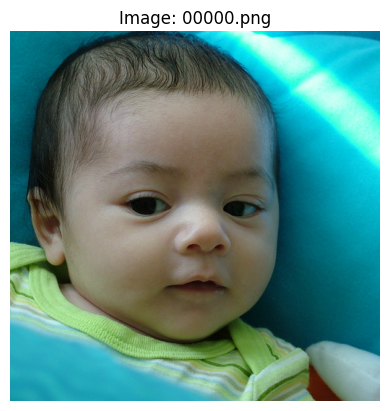

Annotation (00000.json):
[
  {
    "faceId": "866db6af-66ee-4828-b565-994f42571d2f",
    "faceRectangle": {
      "top": 42,
      "left": 32,
      "width": 63,
      "height": 63
    },
    "faceAttributes": {
      "smile": 0.003,
      "headPose": {
        "pitch": 5.4,
        "roll": 1.5,
        "yaw": 15.3
      },
      "gender": "female",
      "age": 0.0,
      "facialHair": {
        "moustache": 0.0,
        "beard": 0.0,
        "sideburns": 0.0
      },
      "glasses": "NoGlasses",
      "emotion": {
        "anger": 0.0,
        "contempt": 0.0,
        "disgust": 0.0,
        "fear": 0.0,
        "happiness": 0.003,
        "neutral": 0.993,
        "sadness": 0.003,
        "surprise": 0.0
      },
      "blur": {
        "blurLevel": "medium",
        "value": 0.55
      },
      "exposure": {
        "exposureLevel": "goodExposure",
        "value": 0.6
      },
      "noise": {
        "noiseLevel": "medium",
        "value": 0.44
      },
      "makeup": {
     

In [13]:
plt.imshow(Image.open(os.path.join(images_dir, "00000.png")))
plt.axis("off")
plt.title("Image: 00000.png")
plt.show()

with open(os.path.join(features_dir, "00000.json")) as f:
    print("Annotation (00000.json):")
    print(json.dumps(json.load(f), indent=2))

Lets further explore this by looking into unqiue pairings of accessories and do a sanity check on a small sample.

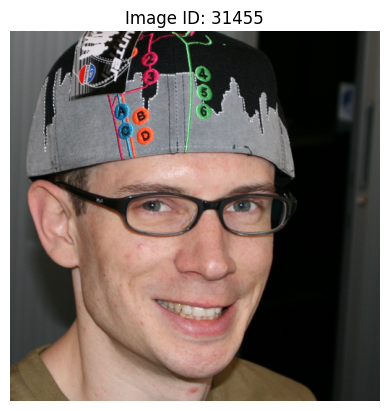

Accessories detected: {'glasses': 1, 'headwear': 1}


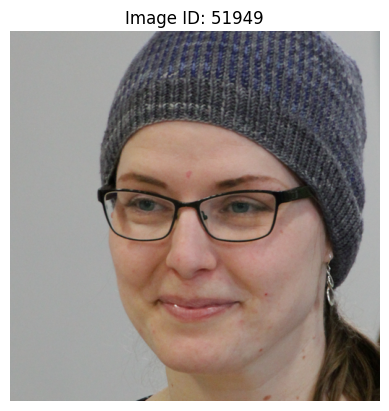

Accessories detected: {'glasses': 1, 'headwear': 1}


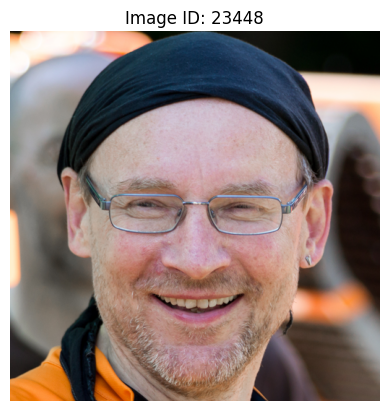

Accessories detected: {'glasses': 1, 'headwear': 1}


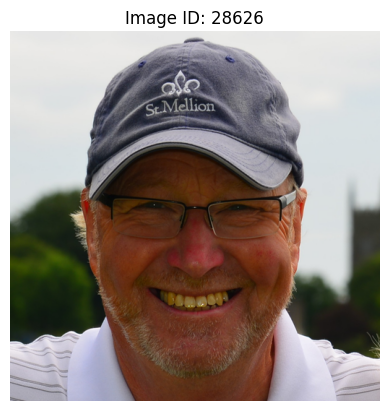

Accessories detected: {'glasses': 1, 'headwear': 1}


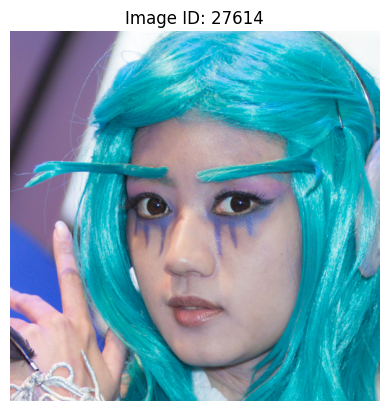

Accessories detected: {'glasses': 1, 'headwear': 1}


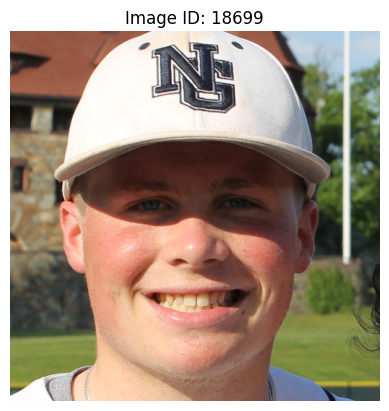

Accessories detected: {'glasses': 1, 'headwear': 1}


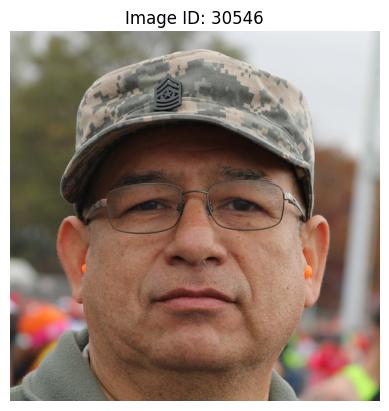

Accessories detected: {'glasses': 1, 'headwear': 1}


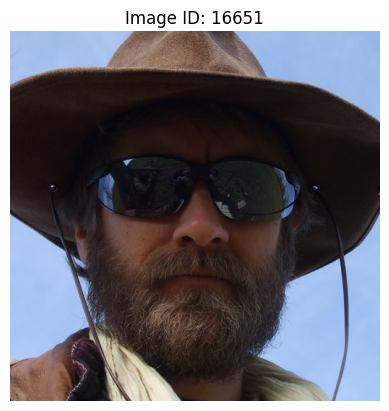

Accessories detected: {'glasses': 1, 'headwear': 1}


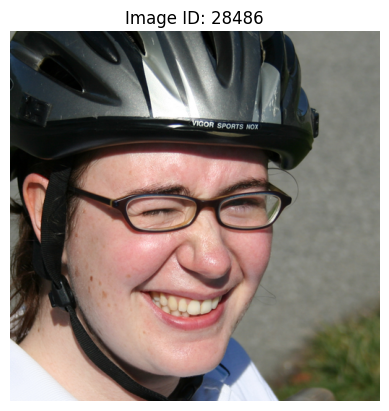

Accessories detected: {'glasses': 1, 'headwear': 1}


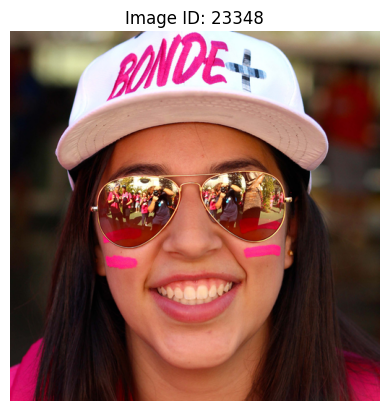

Accessories detected: {'glasses': 1, 'headwear': 1}


In [15]:
accessory_cols = [col for col in df.columns if col != "image_id"]
df_multi_accessory = df[df[accessory_cols].sum(axis=1) >= 2]

sampled_rows = df_multi_accessory.sample(n=10, random_state=42)

for _, row in sampled_rows.iterrows():
    image_path = os.path.join(images_dir, f"{row['image_id']}.png")
    
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Image ID: {row['image_id']}")
    plt.show()
    
    accessories_detected = {col: int(row[col]) for col in accessory_cols if row[col] == 1}
    print(f"Accessories detected: {accessories_detected}")

We can see that 27614 and 18699 do not include both glasses and headwear. I suspect that this is the case of either less than perfect annotation done by the annotation authors (perhaps using some prediction model), which resulted in mis-annotated images. As the source states, the annotations are "good" not "perfect". I cross-checked these images with the github source images, and they do indeed match, so this is not a matter of mismatching ids due to versioning differences.

Let's further look into the mask images, since they're a very small part of the data set (15 entries labeled).

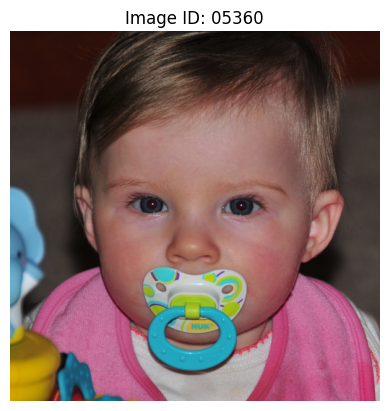

Accessories: {'mask': 1}


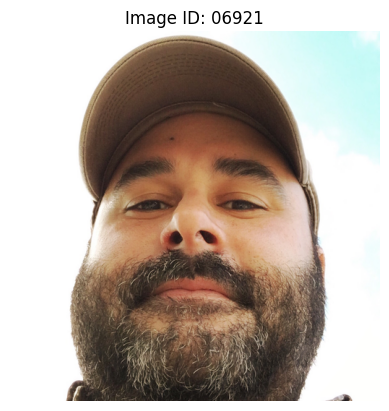

Accessories: {'mask': 1}


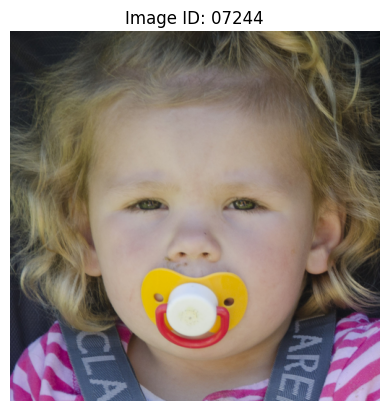

Accessories: {'mask': 1}


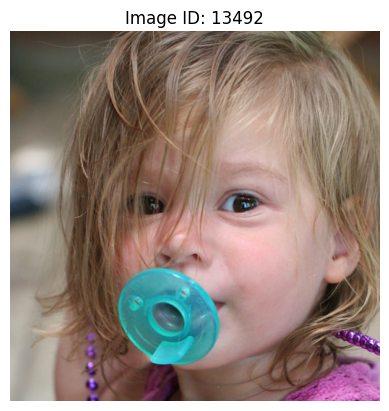

Accessories: {'mask': 1}


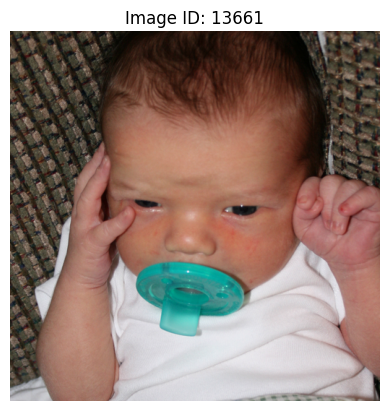

Accessories: {'mask': 1}


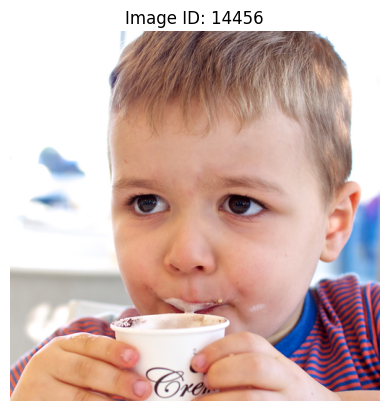

Accessories: {'mask': 1}


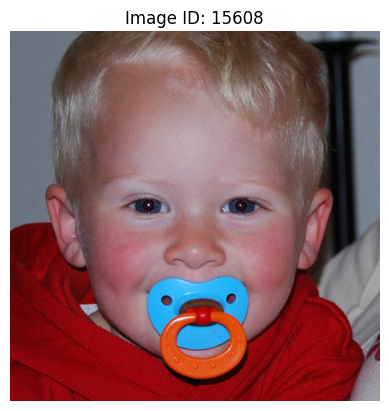

Accessories: {'mask': 1}


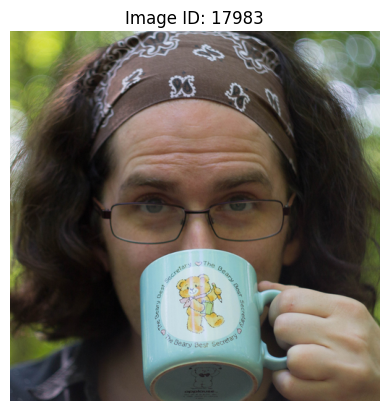

Accessories: {'glasses': 1, 'mask': 1}


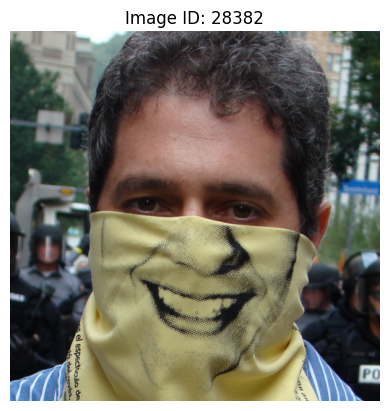

Accessories: {'mask': 1}


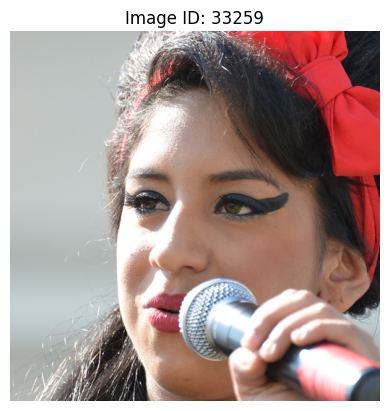

Accessories: {'mask': 1}


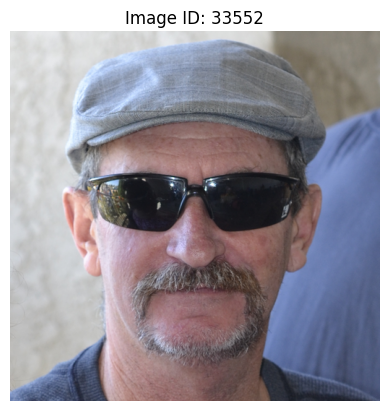

Accessories: {'glasses': 1, 'headwear': 1, 'mask': 1}


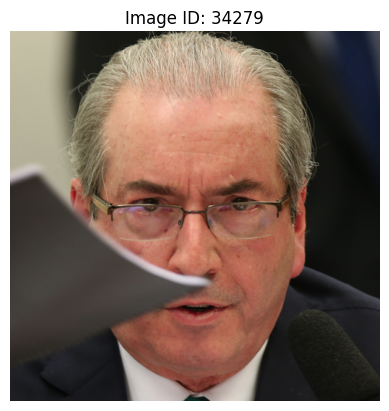

Accessories: {'glasses': 1, 'mask': 1}


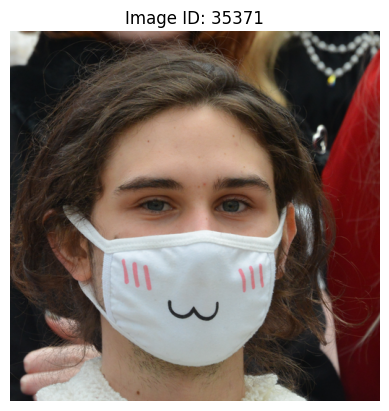

Accessories: {'mask': 1}


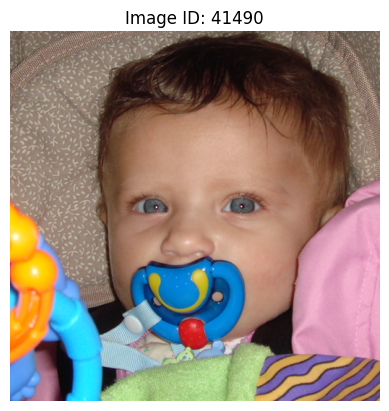

Accessories: {'mask': 1}


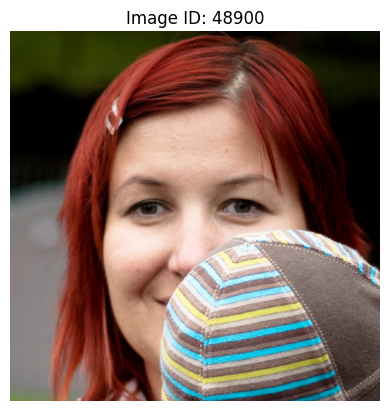

Accessories: {'mask': 1}


In [16]:
accessory_cols = [col for col in df.columns if col != "image_id"]

df_mask = df[df.get("mask", 0) == 1]

for _, row in df_mask.iterrows(): 
    img = Image.open(os.path.join(images_dir, f"{row['image_id']}.png"))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Image ID: {row['image_id']}")
    plt.show()
    
    accessories_present = {col: int(row[col]) for col in accessory_cols if row[col] == 1}
    print("Accessories:", accessories_present)

We can see here that the vast majority of the "mask" annotated images clearly do not have a mask. I suspect that this was caused by a auto annotating model that mistaked some level of covering of the mouth as having a mask on. For my purposes, I will drop the mask data as it represents a very small amount of the dataset and it would not be significant in any sort of generalization at the current magnitude of data.

In [17]:
print("Before filtering:")
print("DataFrame shape:", df.shape)
print("Accessory counts before drop:")
print(df[accessory_cols].sum().sort_values(ascending=False))

df = df[df["mask"] != 1]
df = df.drop(columns=["mask"])

accessory_cols = [col for col in df.columns if col != "image_id"]

print("\nAfter filtering:")
print("DataFrame shape:", df.shape)
print("Accessory counts after drop:")
print(df[accessory_cols].sum().sort_values(ascending=False))

Before filtering:
DataFrame shape: (52001, 4)
Accessory counts before drop:
glasses     9453
headwear    3650
mask          15
dtype: int64

After filtering:
DataFrame shape: (51986, 3)
Accessory counts after drop:
glasses     9450
headwear    3649
dtype: int64


In [50]:
print("Raw (glasses, headwear) pair counts:")
print(df[['glasses', 'headwear']].value_counts().sort_index())

Raw (glasses, headwear) pair counts:
glasses  headwear
0        0           39578
         1            2958
1        0            8759
         1             691
Name: count, dtype: int64


Lets create a simple basic model. Use MobileV2net as our base. downscale our images so it can be used as a input for MobileV2net. Simple train test split. 0.8/0.2 split.

In [ ]:
labels = df[["glasses", "headwear"]].values
image_paths = [os.path.join(images_dir, f"{img_id}.png") for img_id in df["image_id"]]

IMG_SIZE = (224, 224)

def load_and_preprocess_image(path):
    img = load_img(path, target_size=IMG_SIZE)
    return img_to_array(img) / 255.0

X = np.array([load_and_preprocess_image(p) for p in tqdm(image_paths)])
y = labels

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

100%|██████████| 51986/51986 [09:32<00:00, 90.86it/s] 


Show class distribution plots to observe that the distributions are held between splits. And to observe class balance.

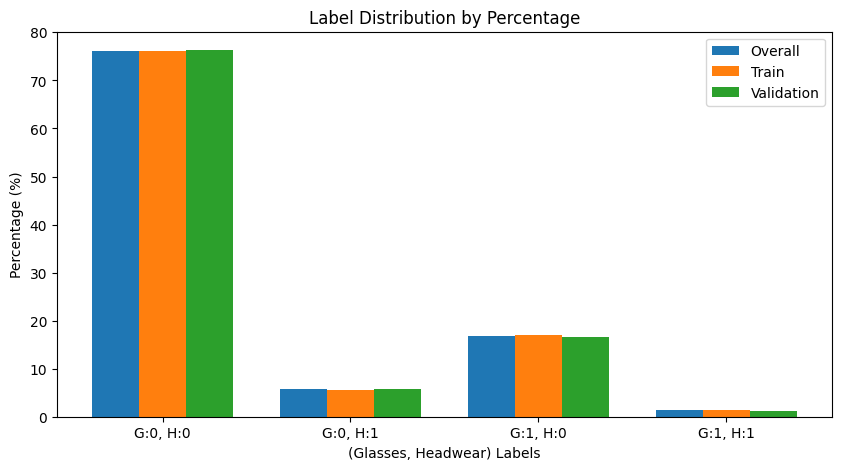

In [55]:
def get_percentage_distribution(y_data):
    df_labels = pd.DataFrame(y_data, columns=["glasses", "headwear"])
    pair_counts = df_labels.value_counts().sort_index()
    pair_percent = (pair_counts / len(df_labels) * 100).round(2)
    return pair_percent

# Get percentage distributions
overall_percent = get_percentage_distribution(labels)
train_percent = get_percentage_distribution(y_train)
val_percent = get_percentage_distribution(y_val)

# Format for plotting
index_labels = [f"G:{g}, H:{h}" for g, h in overall_percent.index]
x = np.arange(len(index_labels))
width = 0.25

# Plot percentages only
plt.figure(figsize=(10, 5))
plt.bar(x - width, overall_percent.values, width, label="Overall")
plt.bar(x, train_percent.values, width, label="Train")
plt.bar(x + width, val_percent.values, width, label="Validation")

plt.xticks(x, index_labels)
plt.xlabel("(Glasses, Headwear) Labels")
plt.ylabel("Percentage (%)")
plt.title("Label Distribution by Percentage")
plt.legend()
plt.show()

With the foremention base model, let just add globalaveragepooling to simplfy the base model output. Add in 2 neuron sigmoid output layer to keep it simple, can extrapolate the 4 seperate classes after fitment and prediction. Also, add early stopping so we don't waste time waiting for these models to fit.

In [ ]:
IMG_SHAPE = (224, 224, 3)

base_model = MobileNetV2(input_shape=IMG_SHAPE, include_top=False, weights="imagenet")
base_model.trainable = False

inputs = Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(2, activation="sigmoid")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [58]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 240s 184ms/step - accuracy: 0.7905 - loss: 0.1310 - val_accuracy: 0.6657 - val_loss: 0.1162
Epoch 2/10
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 222s 171ms/step - accuracy: 0.7556 - loss: 0.1074 - val_accuracy: 0.6315 - val_loss: 0.1160
Epoch 3/10
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 222s 171ms/step - accuracy: 0.7503 - loss: 0.0989 - val_accuracy: 0.6588 - val_loss: 0.1158
Epoch 4/10
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 221s 170ms/step - accuracy: 0.7563 - loss: 0.0980 - val_accuracy: 0.7596 - val_loss: 0.1100
Epoch 5/10
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 221s 170ms/step - accuracy: 0.7556 - loss: 0.0921 - val_accuracy: 0.6810 - val_loss: 0.1134
Epoch 6/10
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 214s 165ms/step - accuracy: 0.7616 - loss: 0.0924 - val_accuracy: 0.7598 - val_loss: 0.1079
Epoch 7/10
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 214s 165ms/step - accuracy: 0.7569 - loss: 0.0918 - val_accuracy: 0.7524 - val_loss: 0.1091
Epoch 8/10
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 217s 167ms/step - ac

## Performance metrics basic model

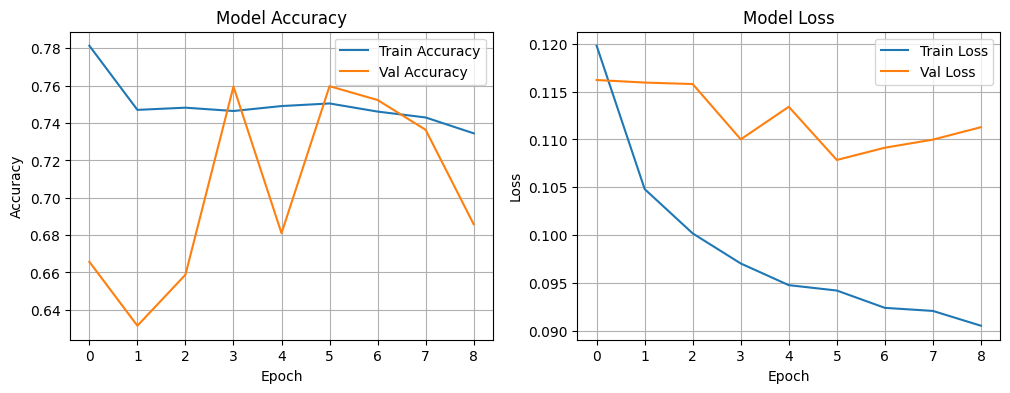

In [59]:
def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.title("Model Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title("Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.show()

plot_training_history(history)


325/325 ━━━━━━━━━━━━━━━━━━━━ 47s 143ms/step


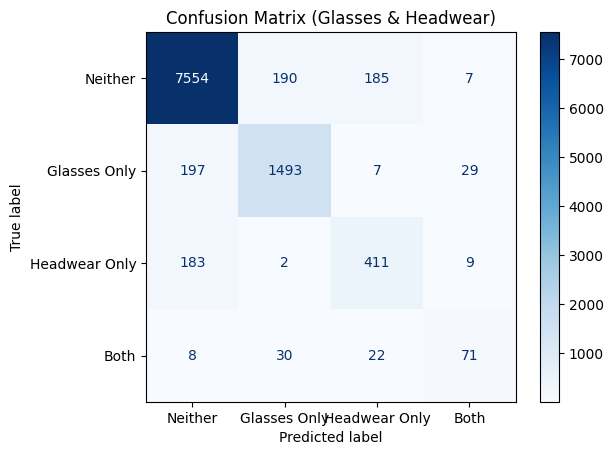

In [ ]:
y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int)

def to_class_index(arr):
    return arr[:, 0] * 1 + arr[:, 1] * 2

y_true_cls = to_class_index(y_val)
y_pred_cls = to_class_index(y_pred)

labels = ["Neither", "Glasses Only", "Headwear Only", "Both"]
cm = confusion_matrix(y_true_cls, y_pred_cls)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Glasses & Headwear)")
plt.show()

In [ ]:
class_totals = cm.sum(axis=1)
correct_preds = np.diag(cm)
class_accuracies = (correct_preds / class_totals * 100).round(2)

for label, acc, total in zip(labels, class_accuracies, class_totals):
    print(f"{label:<15}: {acc:>5.1f}% (n={total})")

total_correct = np.sum(np.diag(cm))
total_samples = np.sum(cm)
total_accuracy = total_correct / total_samples * 100

print(f"\nTotal Accuracy: {total_accuracy:.2f}%")

Neither        :  95.2% (n=7936)
Glasses Only   :  86.5% (n=1726)
Headwear Only  :  67.9% (n=605)
Both           :  54.2% (n=131)

Total Accuracy: 91.64%


Some improvements can continue to be made, let's try updating the model so that it takes a dense 128 layer, maybe that would increase the likelihood of complex patterns to be associated with out 2 output neurons.

In [68]:
base_model = MobileNetV2(input_shape=IMG_SHAPE, include_top=False, weights="imagenet")
base_model.trainable = False

inputs = Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(2, activation='sigmoid')(x)

model_v2 = Model(inputs, outputs)
model_v2.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

model_v2.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [69]:
# Update to detect val_loss to detect overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_v2 = model_v2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 289s 219ms/step - accuracy: 0.7422 - loss: 0.1407 - val_accuracy: 0.6721 - val_loss: 0.1056
Epoch 2/10
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 251s 193ms/step - accuracy: 0.6592 - loss: 0.0990 - val_accuracy: 0.4736 - val_loss: 0.1059
Epoch 3/10
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 248s 190ms/step - accuracy: 0.5926 - loss: 0.0889 - val_accuracy: 0.6707 - val_loss: 0.1028
Epoch 4/10
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 252s 194ms/step - accuracy: 0.6436 - loss: 0.0854 - val_accuracy: 0.4641 - val_loss: 0.1073
Epoch 5/10
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 246s 189ms/step - accuracy: 0.5758 - loss: 0.0780 - val_accuracy: 0.5684 - val_loss: 0.1090
Epoch 6/10
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 247s 190ms/step - accuracy: 0.6010 - loss: 0.0750 - val_accuracy: 0.4510 - val_loss: 0.1227


## Model v2 Metrics

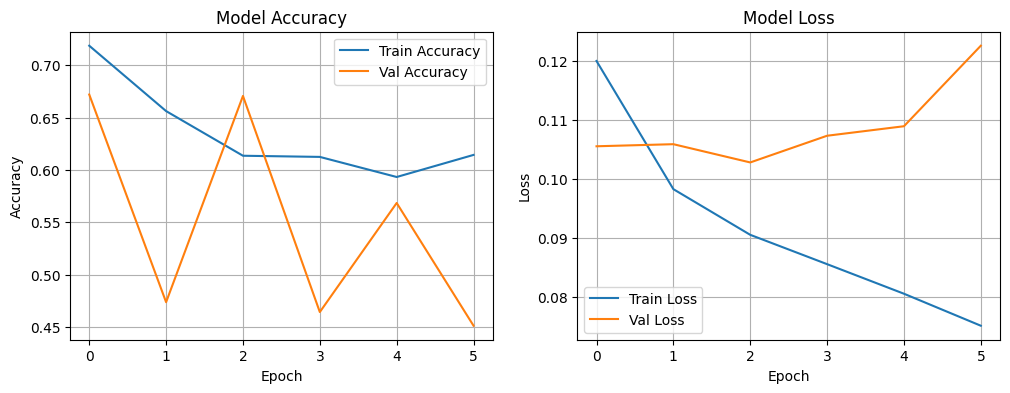

In [70]:
plot_training_history(history_v2)

325/325 ━━━━━━━━━━━━━━━━━━━━ 53s 161ms/step


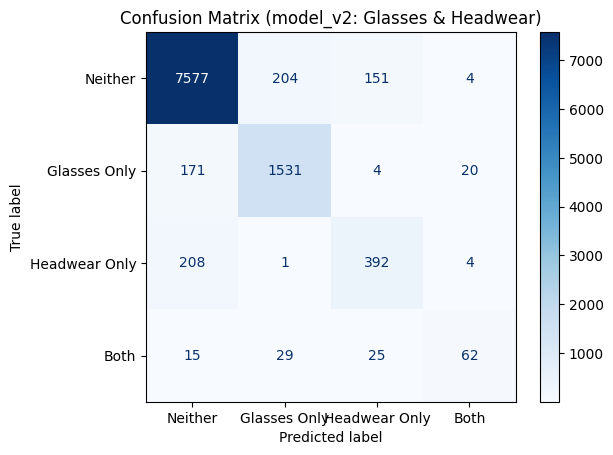

In [ ]:
y_pred_prob_v2 = model_v2.predict(X_val)
y_pred_v2 = (y_pred_prob_v2 > 0.5).astype(int)

y_true_cls_v2 = to_class_index(y_val)
y_pred_cls_v2 = to_class_index(y_pred_v2)

labels = ["Neither", "Glasses Only", "Headwear Only", "Both"]
cm_v2 = confusion_matrix(y_true_cls_v2, y_pred_cls_v2)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_v2, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (model_v2: Glasses & Headwear)")
plt.show()

In [73]:
class_totals = cm_v2.sum(axis=1)
correct_preds = np.diag(cm_v2)
class_accuracies = (correct_preds / class_totals * 100).round(2)

print("\nPer-Class Accuracy (model_v2):")
for label, acc, total in zip(labels, class_accuracies, class_totals):
    print(f"{label:<15}: {acc:>5.1f}% (n={total})")

total_correct = np.sum(correct_preds)
total_samples = np.sum(cm_v2)
total_accuracy = total_correct / total_samples * 100

print(f"\nTotal Accuracy (model_v2): {total_accuracy:.2f}%")


Per-Class Accuracy (model_v2):
Neither        :  95.5% (n=7936)
Glasses Only   :  88.7% (n=1726)
Headwear Only  :  64.8% (n=605)
Both           :  47.3% (n=131)

Total Accuracy (model_v2): 91.96%


Model performed worse with the dense layers, did not expect that, patterns were probably over simplified. Let's just take this model and try down sampling the "both" class. I think it's skewing the model performance.

In [74]:
y_train_class = to_class_index(y_train)

X_neither = X_train[y_train_class == 0]
y_neither = y_train[y_train_class == 0]

X_other = X_train[y_train_class != 0]
y_other = y_train[y_train_class != 0]

print(f"Original 'Neither' count: {len(X_neither)}")
print(f"All other classes count: {len(X_other)}")

Original 'Neither' count: 31642
All other classes count: 9946


In [90]:
fraction_to_keep = 0.3
n_keep = int(len(X_neither) * fraction_to_keep)

X_neither_down = X_neither[:n_keep]
y_neither_down = y_neither[:n_keep]

print(n_keep)

9492


In [91]:
X_balanced = np.concatenate([X_neither_down, X_other])
y_balanced = np.concatenate([y_neither_down, y_other])

X_balanced, y_balanced = shuffle(X_balanced, y_balanced, random_state=42)

print(f"New training size: {len(X_balanced)}")

New training size: 19438


This distribution is already looking a lot better after reducing the size of the "neither" category to 3/10 of it's size. Plenty of image data is still there for good generalization of these model (I think).

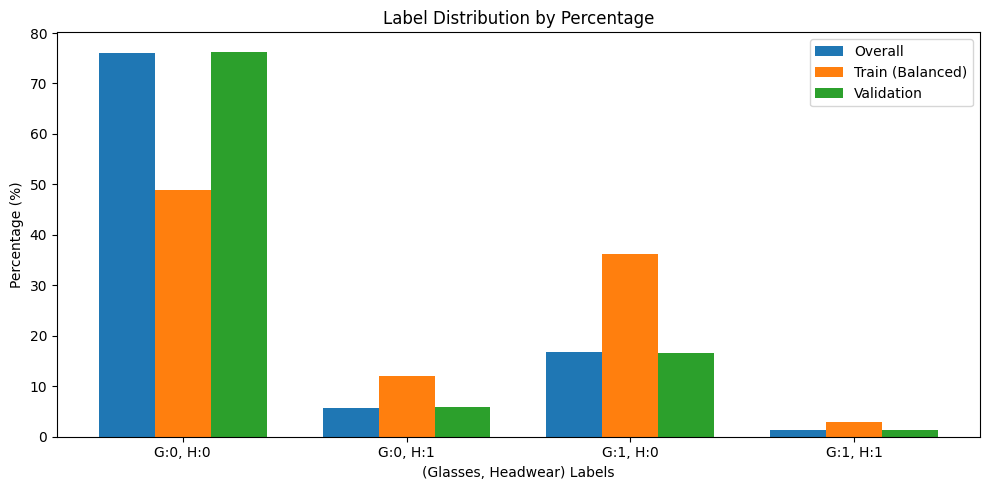

In [103]:
train_percent = get_percentage_distribution(y_balanced)

# Format for plotting
index_labels = [f"G:{g}, H:{h}" for g, h in overall_percent.index]
x = np.arange(len(index_labels))
width = 0.25

# Plot
plt.figure(figsize=(10, 5))
plt.bar(x - width, overall_percent.values, width, label="Overall")
plt.bar(x, train_percent.values, width, label="Train (Balanced)")
plt.bar(x + width, val_percent.values, width, label="Validation")

plt.xticks(x, index_labels)
plt.xlabel("(Glasses, Headwear) Labels")
plt.ylabel("Percentage (%)")
plt.title("Label Distribution by Percentage")
plt.legend()
plt.tight_layout()
plt.show()

In [106]:
history_v3 = model_v2.fit(
    X_balanced, y_balanced,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
608/608 ━━━━━━━━━━━━━━━━━━━━ 153s 251ms/step - accuracy: 0.7696 - loss: 0.0935 - val_accuracy: 0.4789 - val_loss: 0.1342
Epoch 2/10
608/608 ━━━━━━━━━━━━━━━━━━━━ 134s 221ms/step - accuracy: 0.7244 - loss: 0.0824 - val_accuracy: 0.7171 - val_loss: 0.1312
Epoch 3/10
608/608 ━━━━━━━━━━━━━━━━━━━━ 132s 217ms/step - accuracy: 0.7543 - loss: 0.0797 - val_accuracy: 0.4167 - val_loss: 0.1524
Epoch 4/10
608/608 ━━━━━━━━━━━━━━━━━━━━ 135s 223ms/step - accuracy: 0.7177 - loss: 0.0698 - val_accuracy: 0.5792 - val_loss: 0.1395
Epoch 5/10
608/608 ━━━━━━━━━━━━━━━━━━━━ 140s 231ms/step - accuracy: 0.7630 - loss: 0.0640 - val_accuracy: 0.7017 - val_loss: 0.1517


## Model v2 performance downsampled

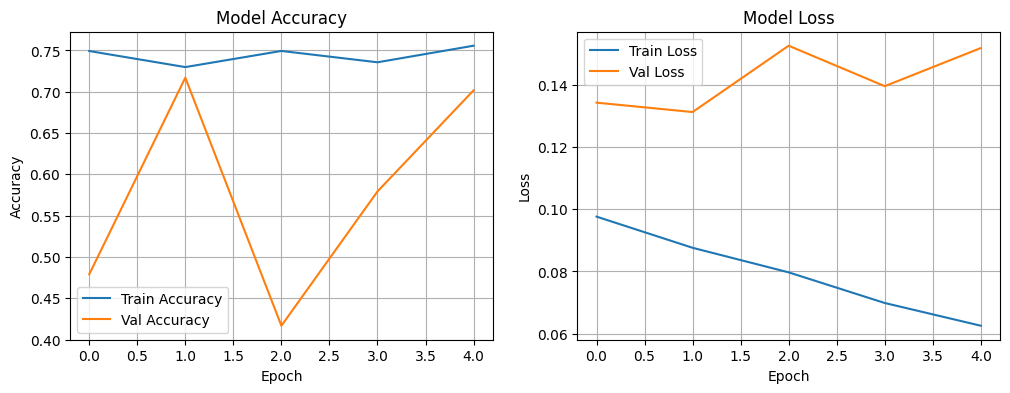

In [107]:
plot_training_history(history_v3)

In [109]:
y_pred_prob_v3 = model_v2.predict(X_val)
y_pred_v3 = (y_pred_prob_v3 > 0.5).astype(int)

y_true_cls_v3 = to_class_index(y_val)
y_pred_cls_v3 = to_class_index(y_pred_v3)

cm_v3 = confusion_matrix(y_true_cls_v3, y_pred_cls_v3)

class_totals = cm_v3.sum(axis=1)
correct_preds = np.diag(cm_v3)
class_accuracies = (correct_preds / class_totals * 100).round(2)

print("\nPer-Class Accuracy (model_v3):")
for label, acc, total in zip(labels, class_accuracies, class_totals):
    print(f"{label:<15}: {acc:>5.1f}% (n={total})")

total_correct = np.sum(correct_preds)
total_samples = np.sum(cm_v3)
total_accuracy = total_correct / total_samples * 100

print(f"\nTotal Accuracy (model_v3): {total_accuracy:.2f}%")

325/325 ━━━━━━━━━━━━━━━━━━━━ 48s 146ms/step

Per-Class Accuracy (model_v3):
Neither        :  91.7% (n=7936)
Glasses Only   :  95.2% (n=1726)
Headwear Only  :  79.7% (n=605)
Both           :  56.5% (n=131)

Total Accuracy (model_v3): 91.17%


That model performs better than the basic model now. Crazy how a simple downsample improves relative class performance that much. Let's try something entirely different. Making each nueron on the output layer represent a class. I think they would definitely make each class explicitly expressed in the CNN. The think compute time would not scale well though if for whatever reason someone decided "we need to detect more accessory types". I believe computation would scale exponentially. But at 4 classes, I think it's reasonable.

In [110]:
base_model = MobileNetV2(input_shape=IMG_SHAPE, include_top=False, weights="imagenet")
base_model.trainable = False

inputs = Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(4, activation='softmax')(x)

model_4class = Model(inputs, outputs)

model_4class.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_4class.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [112]:
y_train_4class = to_class_index(y_train)
y_val_4class = to_class_index(y_val)

In [113]:
y_train_oh = to_categorical(y_train_4class, num_classes=4)
y_val_oh = to_categorical(y_val_4class, num_classes=4)

In [114]:
history_4class = model_4class.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 350s 266ms/step - accuracy: 0.8920 - loss: 0.2921 - val_accuracy: 0.9065 - val_loss: 0.2250
Epoch 2/10
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 345s 265ms/step - accuracy: 0.9265 - loss: 0.1936 - val_accuracy: 0.9123 - val_loss: 0.2249
Epoch 3/10
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 317s 244ms/step - accuracy: 0.9309 - loss: 0.1773 - val_accuracy: 0.9217 - val_loss: 0.2017
Epoch 4/10
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 342s 263ms/step - accuracy: 0.9332 - loss: 0.1757 - val_accuracy: 0.9189 - val_loss: 0.2087
Epoch 5/10
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 369s 284ms/step - accuracy: 0.9388 - loss: 0.1634 - val_accuracy: 0.9179 - val_loss: 0.2075
Epoch 6/10
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 373s 287ms/step - accuracy: 0.9452 - loss: 0.1430 - val_accuracy: 0.9182 - val_loss: 0.2157


## Model 4 class performance

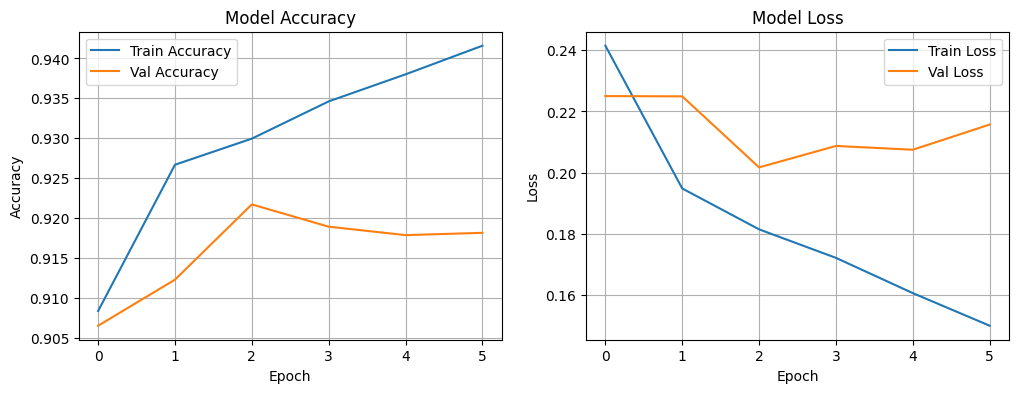

In [115]:
plot_training_history(history_4class)

In [116]:
y_pred_prob_4class = model_4class.predict(X_val)
y_pred_cls_4class = np.argmax(y_pred_prob_4class, axis=1)
y_true_cls_4class = np.argmax(y_val_oh, axis=1)

cm_4class = confusion_matrix(y_true_cls_4class, y_pred_cls_4class)

class_totals = cm_4class.sum(axis=1)
correct_preds = np.diag(cm_4class)
class_accuracies = (correct_preds / class_totals * 100).round(2)

print("\nPer-Class Accuracy (model_4class):")
for label, acc, total in zip(labels, class_accuracies, class_totals):
    print(f"{label:<15}: {acc:>5.1f}% (n={total})")

total_correct = np.sum(correct_preds)
total_samples = np.sum(cm_4class)
total_accuracy = total_correct / total_samples * 100

print(f"\nTotal Accuracy (model_4class): {total_accuracy:.2f}%")

325/325 ━━━━━━━━━━━━━━━━━━━━ 79s 241ms/step

Per-Class Accuracy (model_4class):
Neither        :  94.7% (n=7936)
Glasses Only   :  88.1% (n=1726)
Headwear Only  :  77.5% (n=605)
Both           :  61.8% (n=131)

Total Accuracy (model_4class): 92.17%


Even better relative class accuracy than the last model, I think altering the class balance is key. So first we've removed, now I think we should add. Specifically with data augmentation.

In [118]:
augmenter = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=5,
    fill_mode='nearest'
)

def augment_class(X, y, class_index, n_aug):
    X_class = X[y == class_index]
    y_class = y[y == class_index]

    X_augmented, y_augmented = [], []

    for _ in range(n_aug):
        flow = augmenter.flow(X_class, y_class, batch_size=len(X_class), shuffle=False)
        X_batch, y_batch = next(flow)
        X_augmented.append(X_batch)
        y_augmented.append(y_batch)

    return np.concatenate(X_augmented), np.concatenate(y_augmented)

In [119]:
X_headwear_aug, y_headwear_aug = augment_class(X_train, y_train_4class, class_index=2, n_aug=2)
X_both_aug, y_both_aug = augment_class(X_train, y_train_4class, class_index=3, n_aug=5)

In [120]:
keep_fraction = 0.3
X_neither = X_train[y_train_4class == 0]
y_neither = y_train_4class[y_train_4class == 0]

n_keep = int(len(X_neither) * keep_fraction)
X_neither_down = X_neither[:n_keep]
y_neither_down = y_neither[:n_keep]

In [121]:
print(n_keep)

9492


In [122]:
mask_other = y_train_4class != 0
X_other = X_train[mask_other]
y_other = y_train_4class[mask_other]

In [123]:
X_final = np.concatenate([
    X_neither_down,
    X_other,
    X_headwear_aug,
    X_both_aug
])

y_final = np.concatenate([
    y_neither_down,
    y_other,
    y_headwear_aug,
    y_both_aug
])

The new distribution of the training set with downsampling and augmentation looks more "balanced" and also still emphasizes the most common case, so we should not sacrificing that much overall performance while improving the weakest classes accuracies.

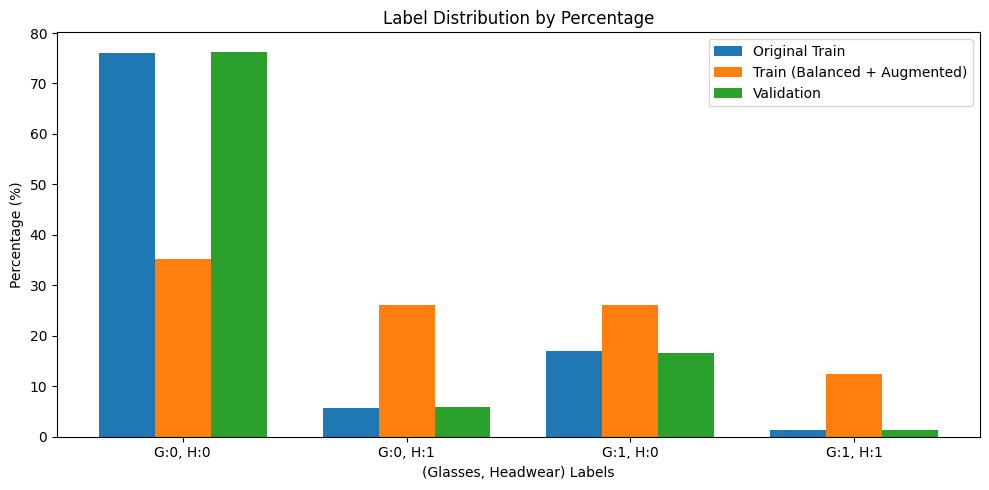

In [126]:
def class_index_to_pair(y):
    return np.array([[i % 2, i // 2] for i in y])

# Updated helper to compute percentages
def get_percentage_distribution(y_data):
    y_pair = class_index_to_pair(y_data)
    df_labels = pd.DataFrame(y_pair, columns=["glasses", "headwear"])
    pair_counts = df_labels.value_counts().sort_index()
    pair_percent = (pair_counts / len(df_labels) * 100).round(2)
    return pair_percent

overall_percent = get_percentage_distribution(y_train_4class)
train_percent = get_percentage_distribution(y_final)
val_percent = get_percentage_distribution(np.argmax(y_val_oh, axis=1))

index_labels = [f"G:{g}, H:{h}" for g, h in overall_percent.index]
x = np.arange(len(index_labels))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, overall_percent.values, width, label="Original Train")
plt.bar(x, train_percent.values, width, label="Train (Balanced + Augmented)")
plt.bar(x + width, val_percent.values, width, label="Validation")

plt.xticks(x, index_labels)
plt.xlabel("(Glasses, Headwear) Labels")
plt.ylabel("Percentage (%)")
plt.title("Label Distribution by Percentage")
plt.legend()
plt.tight_layout()
plt.show()

## Model "final" performance

In [128]:
y_final_oh = to_categorical(y_final, num_classes=4)

history_final = model_4class.fit(
    X_final, y_final_oh,
    validation_data=(X_val, y_val_oh),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 306s 362ms/step - accuracy: 0.9161 - loss: 0.2438 - val_accuracy: 0.8923 - val_loss: 0.3131
Epoch 2/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 276s 328ms/step - accuracy: 0.9396 - loss: 0.1760 - val_accuracy: 0.9167 - val_loss: 0.2290
Epoch 3/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 240s 286ms/step - accuracy: 0.9492 - loss: 0.1493 - val_accuracy: 0.9136 - val_loss: 0.2406
Epoch 4/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 251s 298ms/step - accuracy: 0.9574 - loss: 0.1234 - val_accuracy: 0.8985 - val_loss: 0.3166
Epoch 5/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 258s 306ms/step - accuracy: 0.9621 - loss: 0.1120 - val_accuracy: 0.8909 - val_loss: 0.3327


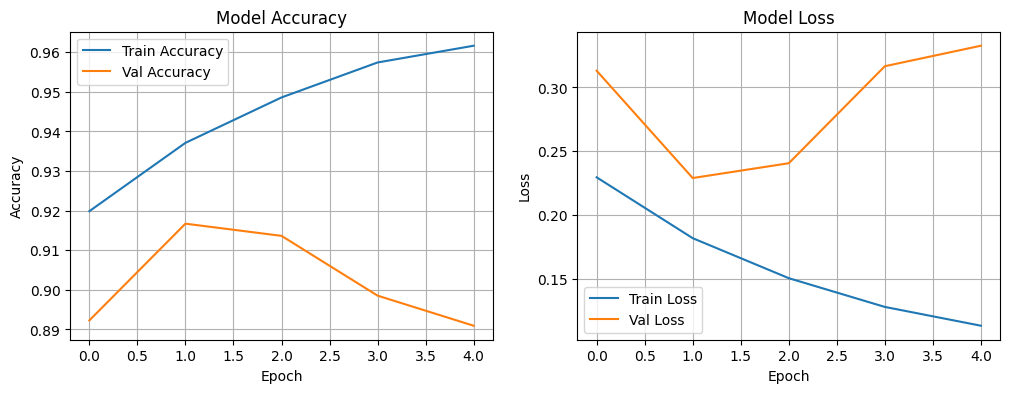

In [129]:
plot_training_history(history_final)

In [130]:
y_pred_prob_4class = model_4class.predict(X_val)
y_pred_cls_4class = np.argmax(y_pred_prob_4class, axis=1)
y_true_cls_4class = np.argmax(y_val_oh, axis=1)

cm_4class = confusion_matrix(y_true_cls_4class, y_pred_cls_4class)

class_totals = cm_4class.sum(axis=1)
correct_preds = np.diag(cm_4class)
class_accuracies = (correct_preds / class_totals * 100).round(2)

print("\nPer-Class Accuracy (model_4class):")
for label, acc, total in zip(labels, class_accuracies, class_totals):
    print(f"{label:<15}: {acc:>5.1f}% (n={total})")

total_correct = np.sum(correct_preds)
total_samples = np.sum(cm_4class)
total_accuracy = total_correct / total_samples * 100

print(f"\nTotal Accuracy (model_4class): {total_accuracy:.2f}%")

325/325 ━━━━━━━━━━━━━━━━━━━━ 76s 233ms/step

Per-Class Accuracy (model_4class):
Neither        :  93.3% (n=7936)
Glasses Only   :  88.6% (n=1726)
Headwear Only  :  84.0% (n=605)
Both           :  67.9% (n=131)

Total Accuracy (model_4class): 91.67%


Impressive, the augmented class acurracies improved as theorized. The currently accuracy distribution for the classes are much closer now. I think the "both" class still have more room to improve. ~75% would be a goodish mark without too much extra fine tuning. I think this is a good point to stop though, I think anymore improvements towards that would take a number of iterations that would blow up the scale of this project.